In [1]:
# Importing setup file
from setup import *

# Link directory to save figures
out_path = "output/p1"
os.makedirs(out_path, exist_ok=True)

### Processing text

In [2]:
# loading the text
text = load_file(translation=False, filePath=BASE_DIR / "data/text.txt")
chars, chars_to_idx, idx_to_chars, encoded_text = vocab(translation=False, dataset=text)

print(f'Using device: {device}')

Using device: cuda


### Hyperparameters

In [3]:
nhead = 2
epochs = 50
num_layers = 2
batch_size = 16
seq_len = [10, 20, 30]
input_size = len(chars)
output_size = input_size

## Helper Functions

In [4]:
def train_model(model, train_loader, val_loader):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    # Initializing variables
    train_losses = []
    val_losses = []
    val_accs = []

    start_time = time.time()

    for epoch in range(epochs):
        # Training loop
        model.train()
        epoch_train_loss = 0.0
        
        for train_x, train_y in train_loader:
            X_train = train_x.to(device)
            Y_train = train_y.to(device)

            optimizer.zero_grad()
            train_output = model(X_train)
            train_loss = criterion(train_output.transpose(1, 2), Y_train)
            train_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_train_loss += train_loss.item()

        train_losses.append(epoch_train_loss / len(train_loader))
        
        # Validation loop
        model.eval()
        epoch_val_loss = 0.0
        epoch_val_acc = 0.0
        with torch.no_grad():
            for val_x, val_y in val_loader:
                X_val = val_x.to(device)
                Y_val = val_y.to(device)

                val_output = model(X_val)
                val_loss = criterion(val_output.transpose(1, 2), Y_val)
                epoch_val_loss += val_loss.item()

                _, predicted = torch.max(val_output, 2)
                val_acc = (predicted == Y_val).float().mean()
                epoch_val_acc += val_acc
                

            val_losses.append(epoch_val_loss / len(val_loader))
            val_accs.append(epoch_val_acc / len(val_loader))

        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1}:\n Loss: {train_loss.item():.3f}, Validation Loss: {val_loss.item():.3f}, Validation Accuracy: {val_acc.item():.4f}')
    
    training_time = time.time() - start_time

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_acc': val_accs,
        'final_train_loss': train_losses[-1],
        'final_val_loss': val_losses[-1],
        'final_val_acc': val_accs[-1],
        'train_time': training_time,
    }

## Main Function



Sequence length: 10
Epoch 10:
 Loss: 0.339, Validation Loss: 0.235, Validation Accuracy: 0.9333
Epoch 20:
 Loss: 0.279, Validation Loss: 0.231, Validation Accuracy: 0.9250
Epoch 30:
 Loss: 0.141, Validation Loss: 0.220, Validation Accuracy: 0.9417
Epoch 40:
 Loss: 0.168, Validation Loss: 0.223, Validation Accuracy: 0.9333
Epoch 50:
 Loss: 0.128, Validation Loss: 0.239, Validation Accuracy: 0.9417


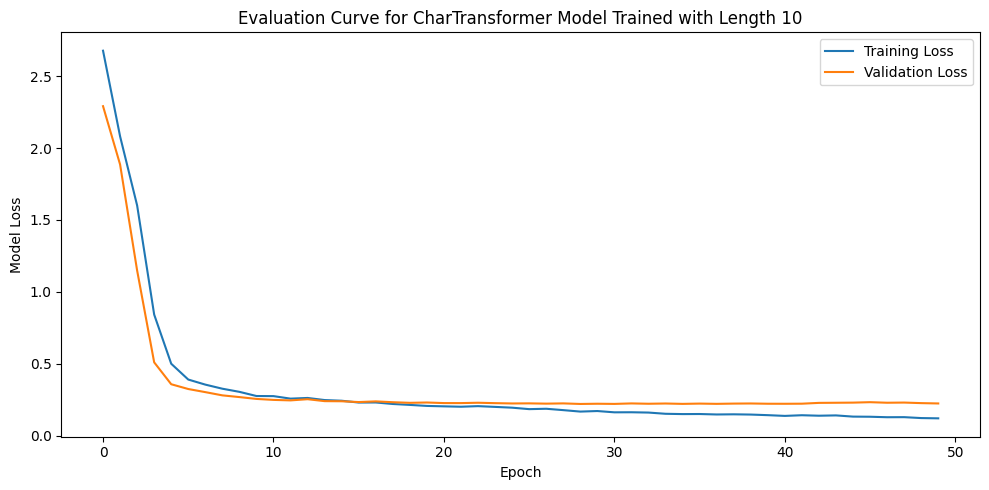



Sequence length: 20
Epoch 10:
 Loss: 0.235, Validation Loss: 0.174, Validation Accuracy: 0.9450
Epoch 20:
 Loss: 0.129, Validation Loss: 0.128, Validation Accuracy: 0.9500
Epoch 30:
 Loss: 0.083, Validation Loss: 0.127, Validation Accuracy: 0.9550
Epoch 40:
 Loss: 0.114, Validation Loss: 0.126, Validation Accuracy: 0.9550
Epoch 50:
 Loss: 0.064, Validation Loss: 0.121, Validation Accuracy: 0.9600


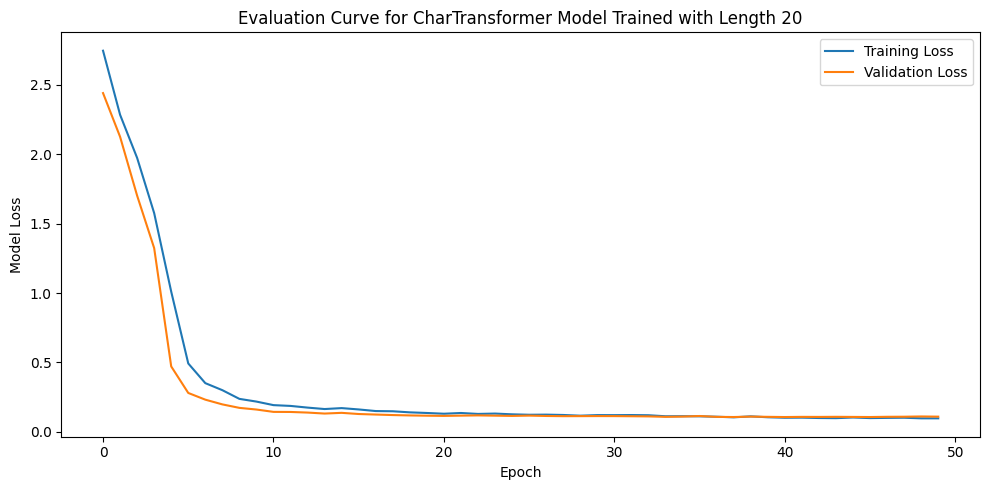



Sequence length: 30
Epoch 10:
 Loss: 0.148, Validation Loss: 0.085, Validation Accuracy: 0.9708
Epoch 20:
 Loss: 0.092, Validation Loss: 0.071, Validation Accuracy: 0.9792
Epoch 30:
 Loss: 0.082, Validation Loss: 0.071, Validation Accuracy: 0.9792
Epoch 40:
 Loss: 0.091, Validation Loss: 0.061, Validation Accuracy: 0.9792
Epoch 50:
 Loss: 0.060, Validation Loss: 0.065, Validation Accuracy: 0.9792


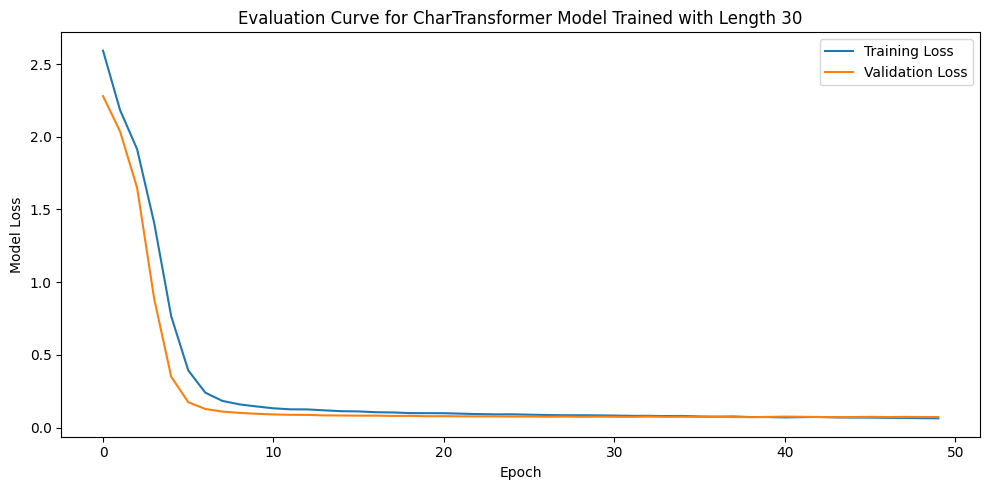



Final Train Loss
Sequence Length: 10	 Value: 0.1215
Sequence Length: 20	 Value: 0.0965
Sequence Length: 30	 Value: 0.0634


Final Val Loss
Sequence Length: 10	 Value: 0.2249
Sequence Length: 20	 Value: 0.1087
Sequence Length: 30	 Value: 0.0722


Val Accuracy
Sequence Length: 10	 Value: 0.9435
Sequence Length: 20	 Value: 0.9700
Sequence Length: 30	 Value: 0.9799


FLOPs
Sequence Length: 10	 Value: 10.564M
Sequence Length: 20	 Value: 21.128M
Sequence Length: 30	 Value: 31.692M


Train Time (s)
Sequence Length: 10	 Value: 34.31
Sequence Length: 20	 Value: 37.07
Sequence Length: 30	 Value: 42.12


No. of Params
Sequence Length: 10	 Value: 1.060M
Sequence Length: 20	 Value: 1.060M
Sequence Length: 30	 Value: 1.060M


Model Size (MB)
Sequence Length: 10	 Value: 7.0099
Sequence Length: 20	 Value: 7.0099
Sequence Length: 30	 Value: 7.0099


In [5]:
results = {}

for seq in seq_len:
    model = charTransformer(input_size, hidden_size, output_size, num_layers, nhead).to(device)
    dataset = CharDataset(encoded_text, seq_len=seq)
    train_loader, val_loader = build_loaders(dataset=dataset, batch_size=batch_size)
    results[seq] = {}
    print("\n")
    print("="*50)
    print(f'Sequence length: {seq}')
    print("="*50)

    metrics = train_model(model, train_loader, val_loader)
    model_size = compute_model_size(model)

    
    sample_input = torch.randint(0, input_size, (1, seq)).to(device)
    flops, params = compute_flops(model, sample_input)

    results[seq] = {
        **metrics,
        'model_size_mb': model_size,
        'complexity': flops,
        'no_params': params,
    }

    plot_loss(results[seq]["train_losses"], results[seq]["val_losses"],
              title=f'Evaluation Curve for CharTransformer Model Trained with Length {seq}',
              path=f'{out_path}/charTransformer_len{seq}_evalCurve')

for metric_name, key, fmt in [
    ("Final Train Loss",    "final_train_loss", ".4f"),
    ("Final Val Loss",      "final_val_loss",   ".4f"),
    ("Val Accuracy",        "final_val_acc",    ".4f"),
    ("FLOPs",               "complexity",       ""),
    ("Train Time (s)",      "train_time",       ".2f"),
    ("No. of Params",       "no_params",           ""),
    ("Model Size (MB)",     "model_size_mb",          ".4f"),
]:
    print("\n")
    print(f'{metric_name}')
    for seq in seq_len:
        value = results[seq][key]
        try:
            print(f'Sequence Length: {seq}\t Value: {value:{fmt}}')
        except (ValueError, TypeError):
            print(f'Sequence Length: {seq}\t Value: {value}')